In [6]:
from PIL import Image
import numpy as np

# Load the image
image_path = "C:/Users/prath/Downloads/d1.jpg"
image = Image.open(image_path)

# Resize the image for faster processing (optional)
image = image.resize((100, 100))

# Convert image to numpy array
image_data = np.array(image)

# Reshape the image data to a 2D array of RGB values
pixels = image_data.reshape((-1, 3))

# Normalize pixel values to [0, 1]
pixels = pixels / 255.0

In [7]:
from minisom import MiniSom
# Define SOM parameters
som_size = 10  # Size of the SOM grid (10x10)
input_len = 3  # RGB has 3 input features
sigma = 1.0    # Spread of the neighborhood function
learning_rate = 0.5
iterations = 1000

# Initialize the SOM
som = MiniSom(som_size, som_size, input_len, sigma=sigma, learning_rate=learning_rate)

# Train the SOM
som.train(pixels, iterations)

In [8]:
# Map each pixel to its closest neuron
quantized_pixels = np.array([som.winner(p) for p in pixels])

# Create a compressed image by assigning each pixel the weight vector of its winning neuron
compressed_pixels = np.array([som.get_weights()[x, y] for x, y in quantized_pixels])

# Reshape the compressed pixels back to the original image shape
compressed_image_data = compressed_pixels.reshape(image_data.shape)

# Convert the compressed image data back to an image
compressed_image = Image.fromarray((compressed_image_data * 255).astype(np.uint8))


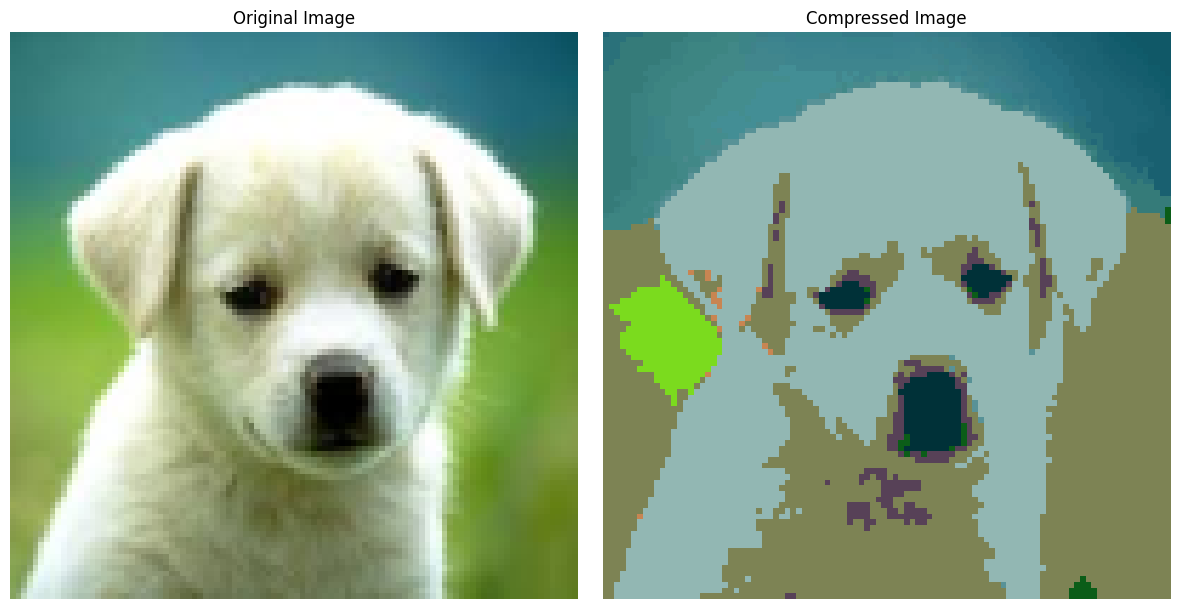

In [9]:
import matplotlib.pyplot as plt

# Plot the original and compressed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_data)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(compressed_image_data)
axes[1].set_title("Compressed Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()
